In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/aqi_cleaned.csv")

df.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,year,month,day,weekday,Season
0,0,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,209.0,2,2015,1,29,3,3
1,0,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,328.0,5,2015,1,30,4,3
2,0,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,514.0,4,2015,1,31,5,3
3,0,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,782.0,4,2015,2,1,6,3
4,0,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,914.0,4,2015,2,2,0,3


In [3]:
X = df.drop(["AQI","AQI_Bucket"], axis=1)

y = df["AQI"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(19880, 17)
(4970, 17)


In [5]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [6]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")

print("MAE :", lr_mae)

print("RMSE :", lr_rmse)

print("R2 :", lr_r2)

Linear Regression
MAE : 31.038931130812607
RMSE : 59.159726124634666
R2 : 0.8088652094131445


In [29]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [30]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

print("R2 :", rf_r2)

Random Forest
MAE : 20.84361575934178
RMSE : 41.0377781465478
R2 : 0.908028109391145


In [9]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [10]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("XGBoost")

print("MAE :", xgb_mae)

print("RMSE :", xgb_rmse)

print("R2 :", xgb_r2)

XGBoost
MAE : 20.68683632365175
RMSE : 42.005041937667855
R2 : 0.90364144453661


In [31]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

results.sort_values(
    by="R2",
    ascending=False
)

,Model,RMSE,R2
1,Random Forest,41.037778,0.908028
2,XGBoost,42.005042,0.903641
0,Linear Regression,59.159726,0.808865


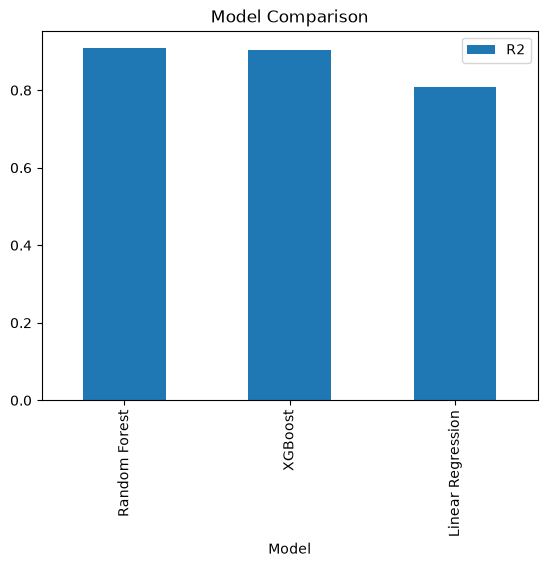

In [32]:
results.sort_values(
    by="R2",
    ascending=False
).plot(
    x="Model",
    y="R2",
    kind="bar"
)

plt.title("Model Comparison")

plt.savefig(
    "../screenshots/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [33]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [14]:
import os

os.listdir("../models")

['random_forest_model.pkl']

In [15]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,PM2.5,0.489555
7,CO,0.365196
3,NO,0.036526
2,PM10,0.036031
9,O3,0.012453
5,NOx,0.010043
8,SO2,0.008071
11,Toluene,0.007254
4,NO2,0.006164
14,day,0.005702


In [25]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

In [26]:
import os

os.listdir("../data/processed")

['aqi_cleaned.csv', 'feature_importance.csv']

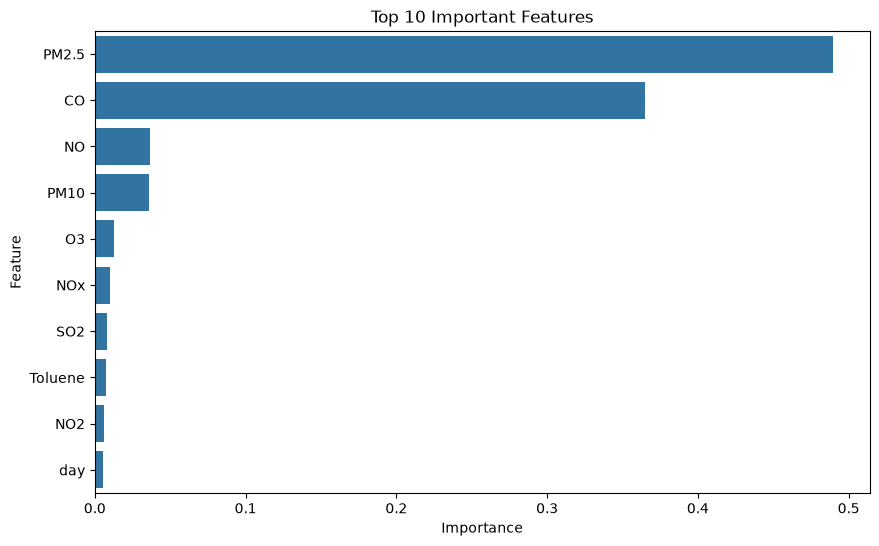

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig(
    "../screenshots/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
import shap

explainer = shap.TreeExplainer(rf)

sample = X_test.iloc[:100]

shap_values = explainer.shap_values(sample)

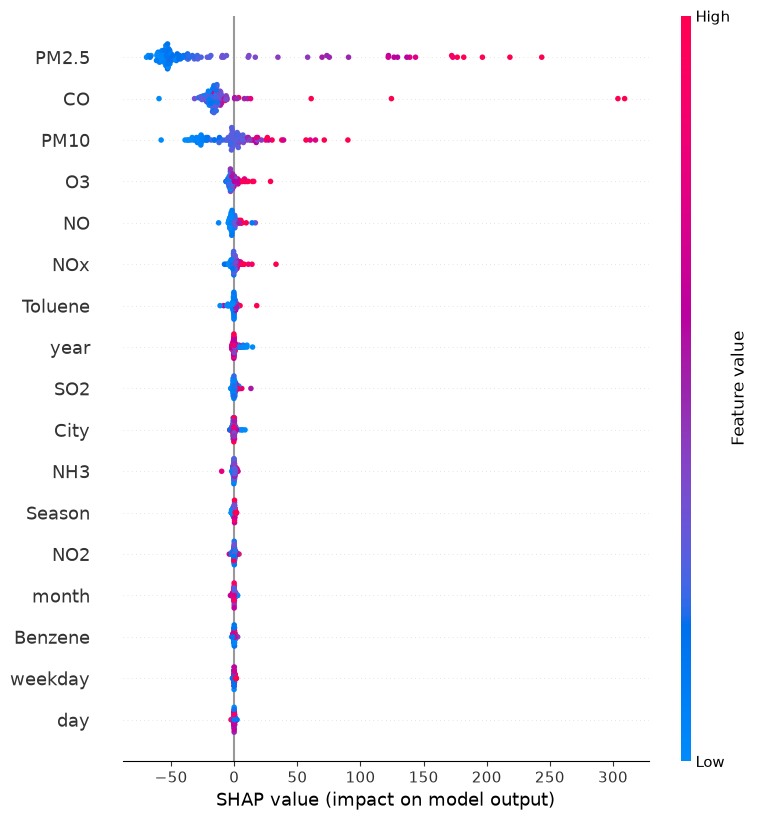

In [18]:
shap.summary_plot(
    shap_values,
    sample
)

In [19]:
plt.savefig(
    "../screenshots/shap_summary.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [20]:
X.columns.tolist()

['City',
 'PM2.5',
 'PM10',
 'NO',
 'NO2',
 'NOx',
 'NH3',
 'CO',
 'SO2',
 'O3',
 'Benzene',
 'Toluene',
 'year',
 'month',
 'day',
 'weekday',
 'Season']

In [21]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [22]:
import os

os.listdir("../models")

['random_forest_model.pkl']

In [23]:
loaded_model = joblib.load(
    "../models/random_forest_model.pkl"
)

loaded_model

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,PM2.5,0.489555
7,CO,0.365196
3,NO,0.036526
2,PM10,0.036031
9,O3,0.012453
5,NOx,0.010043
8,SO2,0.008071
11,Toluene,0.007254
4,NO2,0.006164
14,day,0.005702


In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig(
    "../screenshots/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [27]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf)

sample = X_test.iloc[:100]

shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample,
    show=False
)

plt.savefig(
    "../screenshots/shap_summary.png",
    bbox_inches="tight"
)

plt.close()

In [28]:
import os

os.listdir("../screenshots")

['aqi_distribution.png',
 'aqi_trend.png',
 'correlation_heatmap.png',
 'feature_importance.png',
 'missing_values.png',
 'model_comparison.png',
 'shap_summary.png',
 'top_10_polluted_cities.png']